In [1]:
# load libraries
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import os
import math
import ast

import torch
pd.set_option('display.max_columns', None)

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
experiment_results = pd.read_csv("experiment_results/experiment_results_final_benchmark_07222025.csv")
print(experiment_results.shape)
experiment_results.head()

(811, 26)


,Unnamed: 0,experiment_id,model,freeze_layers,dropout_rate,l2-penalty,optimizer,epochs,learning_rate,lr_scheduler_type,train_loss_history,train_roc_auc_history,train_pr_auc_history,train_acc_history,val_loss_history,val_roc_auc_history,val_pr_auc_history,val_acc_history,train_loss,train_roc_auc,train_pr_auc,train_acc,val_loss,val_roc_auc,val_pr_auc,val_acc
0,0,1,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00001,StepLR,"[0.7677282353413025, 0.7067361010065962, 0.691...","[0.499430405965203, 0.5642087821043911, 0.5548...","[0.6138179898262024, 0.646019697189331, 0.6467...","[0.4947468936443329, 0.5950334072113037, 0.583...","[0.7092869424412394, 0.6918016743456197, 0.722...","[0.5321494182486222, 0.44840783833435394, 0.50...","[0.6192221641540527, 0.596264123916626, 0.6191...","[0.5897436141967773, 0.5555555820465088, 0.538...",0.767728,0.499430,0.613818,0.494747,0.709287,0.532149,0.619222,0.589744
1,1,2,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00001,CosineAnnealingWarmRestarts,"[0.728818148346093, 0.6946324272848018, 0.6875...","[0.5615295805333088, 0.5594218908220565, 0.558...","[0.6501603722572327, 0.6492091417312622, 0.650...","[0.5663801431655884, 0.5959885120391846, 0.590...","[0.7033858340010684, 0.6879486344818376, 0.695...","[0.4797917942437232, 0.5030618493570116, 0.521...","[0.5789679288864136, 0.6239730715751648, 0.643...","[0.5897436141967773, 0.5641025900840759, 0.564...",0.679981,0.558618,0.643018,0.596944,0.676083,0.544703,0.678314,0.632479
2,2,3,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00010,StepLR,"[0.9750317388642028, 0.7559583458085228, 0.683...","[0.48983744515020405, 0.5525982693546903, 0.55...","[0.6053346395492554, 0.6566359400749207, 0.651...","[0.5119388699531555, 0.5721107721328735, 0.589...","[0.8120443230001335, 0.7527669270833334, 0.736...","[0.5832823025107164, 0.43478260869565216, 0.52...","[0.7245486974716187, 0.5707476735115051, 0.654...","[0.5299145579338074, 0.5897436141967773, 0.521...",0.755958,0.552598,0.656636,0.572111,0.752767,0.434783,0.570748,0.589744
3,3,4,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00010,CosineAnnealingWarmRestarts,"[0.8838365731517133, 0.7068022952949647, 0.682...","[0.5478900088987082, 0.5425009205560158, 0.562...","[0.6408112049102783, 0.6306596994400024, 0.658...","[0.5587392449378967, 0.5893027782440186, 0.605...","[0.743416028145032, 0.6974972455929487, 0.6922...","[0.5284751990202082, 0.5278628291488059, 0.549...","[0.6523077487945557, 0.6402071118354797, 0.668...","[0.5128205418586731, 0.5470085740089417, 0.538...",0.685774,0.549622,0.652212,0.577841,0.706475,0.426516,0.533404,0.598291
4,4,5,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00100,StepLR,"[2.059432396802201, 0.6889442728037137, 0.6698...","[0.4889188069594035, 0.5492842676976895, 0.587...","[0.6025617718696594, 0.6485717296600342, 0.665...","[0.5100286602973938, 0.5749761462211609, 0.611...","[0.7411092122395834, 0.6939999833066239, 0.682...","[0.5514390691977955, 0.5639926515615432, 0.548...","[0.6186792850494385, 0.646340012550354, 0.6644...","[0.6153846383094788, 0.5384615659713745, 0.547...",2.059432,0.488919,0.602562,0.510029,0.741109,0.551439,0.618679,0.615385


In [4]:
experiment_results.groupby('model').size()

model
ConvNeXt-base-pretrained         90
ConvNeXt-base-pretrained-clip    90
ConvNeXt-base-scratch            90
ResNet-50-pretrained             90
ResNet-50-pretrained-clip        90
ResNet-50-scratch                90
ViT-b32-pretrained               90
ViT-b32-pretrained-clip          90
ViT-b32-scratch                  91
dtype: int64

# Using Resnet to plot the Loss metrics across epochs for Pre-trained and Scratch models in training and validation dataset 

In [5]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by=['val_acc', 'val_roc_auc'], ascending = False).groupby("model").first()[['experiment_id', 'val_acc', 'val_roc_auc', 'val_pr_auc', 'val_loss','val_pr_auc_history',  'val_acc_history',  'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss','train_loss_history']]


,experiment_id,val_acc,val_roc_auc,val_pr_auc,val_loss,val_pr_auc_history,val_acc_history,train_roc_auc,train_pr_auc,train_acc,train_loss,train_loss_history
model,,,,,,,,,,,,
ConvNeXt-base-pretrained,46,0.803419,0.861604,0.919166,0.854010,"[0.8495288491249084, 0.8886561989784241, 0.891...","[0.6495726704597473, 0.7094017267227173, 0.692...",0.999996,0.999998,0.999045,0.010171,"[0.6250131747328678, 0.4505686718959863, 0.342..."
ConvNeXt-base-pretrained-clip,2,0.846154,0.902327,0.941156,0.490511,"[0.8795718550682068, 0.8981870412826538, 0.910...","[0.7435897588729858, 0.7435897588729858, 0.752...",0.992791,0.995570,0.962751,0.113731,"[0.6139860399131447, 0.47264862789237855, 0.38..."
ConvNeXt-base-scratch,56,0.658120,0.607165,0.672875,0.664588,"[0.6806093454360962, 0.6685093641281128, 0.684...","[0.5726495981216431, 0.5726495981216431, 0.564...",0.566098,0.660875,0.594078,0.720223,"[0.7390447869797263, 0.7331166672729376, 0.730..."
ResNet-50-pretrained,64,0.811966,0.871555,0.928704,0.536489,"[0.8424817323684692, 0.8784760236740112, 0.881...","[0.6410256624221802, 0.6752136945724487, 0.649...",0.999563,0.999722,0.986628,0.058730,"[0.6393139974891058, 0.5110071686869478, 0.399..."
ResNet-50-pretrained-clip,51,0.811966,0.861911,0.910722,0.738837,"[0.8804112076759338, 0.8804120421409607, 0.906...","[0.6666666865348816, 0.752136766910553, 0.7521...",0.999755,0.999850,0.995224,0.027657,"[0.5530227325934963, 0.3068361582933661, 0.138..."
ResNet-50-scratch,17,0.794872,0.812921,0.852441,0.525099,"[0.6493244171142578, 0.6674836277961731, 0.747...","[0.4017094075679779, 0.6410256624221802, 0.658...",0.868704,0.907902,0.796562,0.436773,"[0.9993066979001108, 0.7354116029930661, 0.619..."
ViT-b32-pretrained,38,0.820513,0.862829,0.922369,0.595384,"[0.8586947917938232, 0.8807087540626526, 0.890...","[0.692307710647583, 0.7094017267227173, 0.7350...",0.997538,0.998508,0.981853,0.083455,"[0.6841313490553367, 0.5413686612046322, 0.469..."
ViT-b32-pretrained-clip,50,0.837607,0.876607,0.933870,0.609752,"[0.8675445318222046, 0.8959347009658813, 0.886...","[0.7094017267227173, 0.7435897588729858, 0.726...",0.994571,0.996331,0.974212,0.080009,"[0.5887546776131208, 0.40596503810645745, 0.36..."
ViT-b32-scratch,62,0.692308,0.639927,0.689035,0.640606,"[0.7253473997116089, 0.6808043718338013, 0.693...","[0.5470085740089417, 0.6752136945724487, 0.658...",0.598751,0.696440,0.607450,0.694077,"[0.8379341351382484, 0.7413221940383984, 0.691..."


In [6]:
experiment_results.columns

Index(['Unnamed: 0', 'experiment_id', 'model', 'freeze_layers', 'dropout_rate',
       'l2-penalty', 'optimizer', 'epochs', 'learning_rate',
       'lr_scheduler_type', 'train_loss_history', 'train_roc_auc_history',
       'train_pr_auc_history', 'train_acc_history', 'val_loss_history',
       'val_roc_auc_history', 'val_pr_auc_history', 'val_acc_history',
       'train_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'val_loss',
       'val_roc_auc', 'val_pr_auc', 'val_acc'],
      dtype='object')

# CovNeXt models Test vs Validation metrics visualization

In [7]:
plt.rcParams['font.size'] = 8

In [8]:
# # Define the common model type to compare optimizers for
# common_model_type = 'ConvNeXt-base-pretrained-clip' # Or pick ConvNeXt-base, ViT-B-32, etc.

# # Define the two optimization strategies
# optimizer_type_1 = 'StepLR'
# optimizer_type_2 = 'CosineAnnealingWarmRestarts' 

# # Configuration for Plotting (unchanged from previous working version)
# OUTPUT_DIR = "performance_plots"
# os.makedirs(OUTPUT_DIR, exist_ok=True)
# FIGURE_WIDTH = 5 
# FIGURE_HEIGHT = 3.25 * 0.65 # Adjusted height to maintain aspect ratio
# # FONTSIZE_TITLE = 18
# # FONTSIZE_SUBPLOT_TITLE = 16
# # FONTSIZE_LABELS = 16
# # FONTSIZE_TICKS = 16
# # FONTSIZE_LEGEND = 16
# DPI = 300
# TICK_INTERVAL = 2 

# # Create the figure and two subplots side-by-side
# fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=DPI, sharey=True)

# # Process and Plot for Optimizer Type 1
# # Filter for the common model type AND the specific optimizer type
# df_opt1 = experiment_results[experiment_results['freeze_layers'] == True]

# best_opt1_model_row = df_opt1.sort_values(by='val_acc', ascending=False).iloc[0]

# # Extract and convert history data
# train_loss_history_opt1 = ast.literal_eval(best_opt1_model_row['train_loss_history'])
# val_loss_history_opt1 = ast.literal_eval(best_opt1_model_row['val_loss_history'])
# NUM_EPOCHS = val_loss_history_opt1.index(None)

# # Plot on the first subplot (axes[0])
# axes[0].plot(val_loss_history_opt1, color='lightcoral')
# axes[0].plot(train_loss_history_opt1, color='skyblue')
# # axes[0].set_xticks(np.arange(0, NUM_EPOCHS, TICK_INTERVAL))
# axes[0].set_title(f'Step Scheduler')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Loss')
# axes[0].tick_params(axis='x')
# axes[0].tick_params(axis='y')
# axes[0].grid(axis='both', linestyle='--', alpha=0.7)
# # axes[0].legend()

# # Process and Plot for Optimizer Type 2 (e.g., Cosine Annealing)
# # Filter for the common model type AND the specific optimizer type
# df_opt1 = experiment_results[experiment_results['freeze_layers'] == False]


# best_opt2_model_row = df_opt2.sort_values(by='val_acc', ascending=False).iloc[0]

# # Extract and convert history data
# train_loss_history_opt2 = ast.literal_eval(best_opt2_model_row['train_loss_history'])
# val_loss_history_opt2 = ast.literal_eval(best_opt2_model_row['val_loss_history'])
# NUM_EPOCHS = val_loss_history_opt2.index(None)

# axes[1].plot(val_loss_history_opt2, label='Validation Loss', color='lightcoral')
# axes[1].plot(train_loss_history_opt2, label='Training Loss', color='skyblue')
# # axes[1].set_xticks(np.arange(0, NUM_EPOCHS, TICK_INTERVAL))
# axes[1].set_title(f'Cosine Annealing Scheduler')
# axes[1].set_xlabel('Epoch')
# # axes[1].set_ylabel('Loss', fontsize=FONTSIZE_LABELS)
# axes[1].tick_params(axis='x')
# axes[1].tick_params(axis='y')
# axes[1].grid(axis='both', linestyle='--', alpha=0.7)
# # axes[1].legend()

# fig.legend(loc = 'lower center', ncol = 2, )
# # Add a main title for the entire figure
# fig.suptitle(f'ConvNeXt Learning Curves', y = 1.125)

# # Adjust layout
# # plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])
# plt.subplots_adjust(bottom = 0.325, top = 0.95, wspace = 0.1)

# # Save and display the plot
# plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves_by_scheduler.png"), bbox_inches='tight')
# plt.show()

Unnamed: 0                                                              55
experiment_id                                                           56
model                                                ConvNeXt-base-scratch
freeze_layers                                                        False
dropout_rate                                                           0.5
l2-penalty                                                             0.0
optimizer                                                             Adam
epochs                                                                  50
learning_rate                                                      0.00001
lr_scheduler_type                              CosineAnnealingWarmRestarts
train_loss_history       [0.7390447869797263, 0.7331166672729376, 0.730...
train_roc_auc_history    [0.5650967350946638, 0.5448425849212924, 0.557...
train_pr_auc_history     [0.6591044664382935, 0.6481751203536987, 0.637...
train_acc_history        

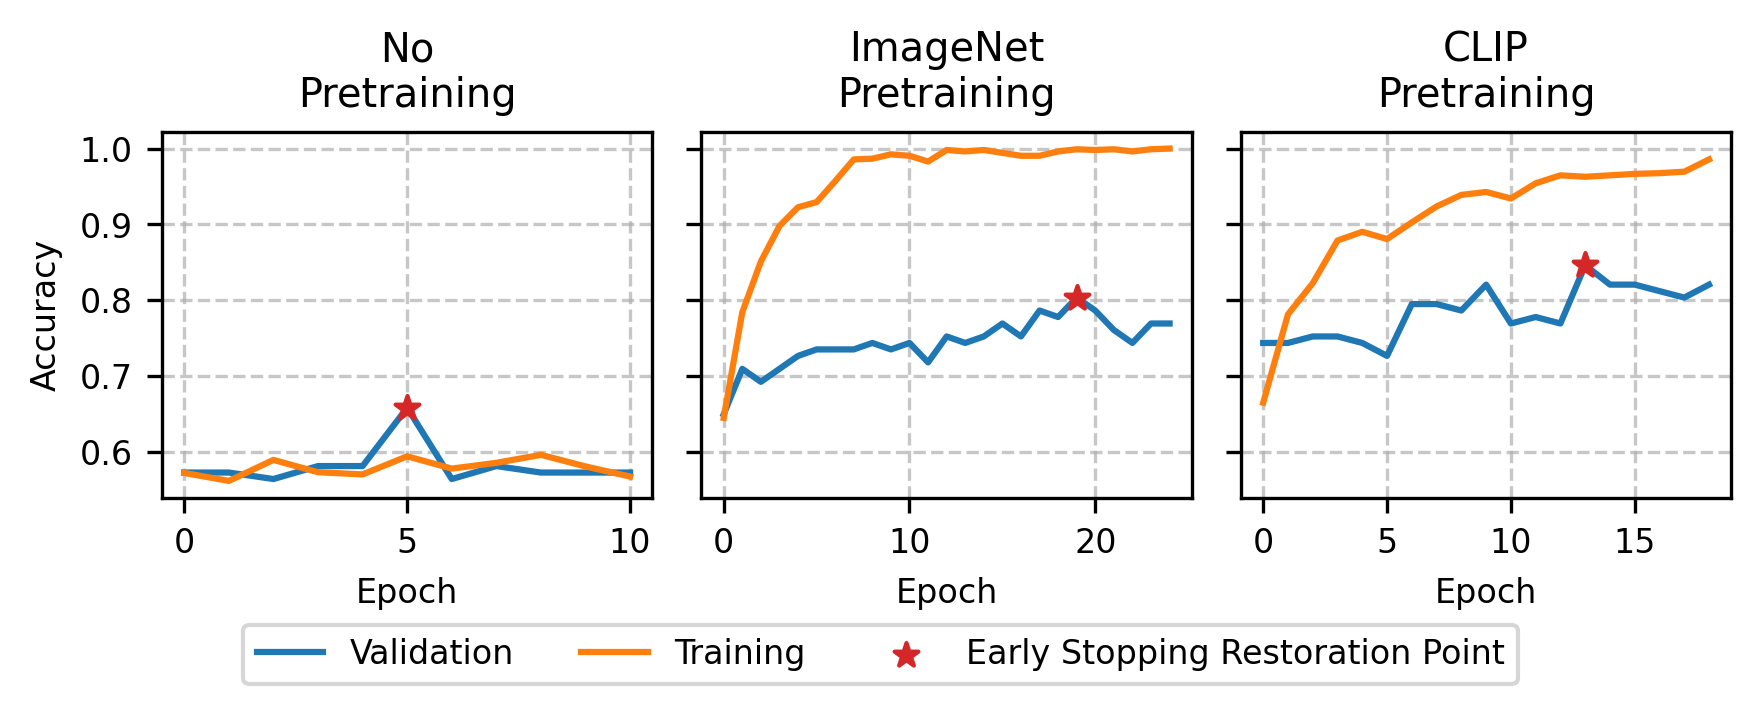

In [86]:
# Define model names
model_type_1 = 'ConvNeXt-base-scratch'
model_type_2 = 'ConvNeXt-base-pretrained'
model_type_3 = 'ConvNeXt-base-pretrained-clip'

# Configuration for Plotting
OUTPUT_DIR = "performance_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURE_WIDTH = 6.75
FIGURE_HEIGHT = 3.25 * 0.6 # Adjusted height to maintain aspect ratio
# FONTSIZE_TITLE = 20
# FONTSIZE_SUBPLOT_TITLE = 18
# FONTSIZE_LABELS = 16
# FONTSIZE_TICKS = 12
# FONTSIZE_LEGEND = 16
DPI = 300
TICK_INTERVAL = 5
# Create the figure and two subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=DPI, sharey=True)

## Subplot 1
# Process and Plot for Model Type 1: ResNet-50-pretrained
cov_pre_df = experiment_results[experiment_results['model'] == model_type_1]

# Get the best model based on validation accuracy
best_cov_pre_model_row = cov_pre_df.sort_values(by=['val_acc', 'val_roc_auc'], ascending=False).iloc[0]
# best_cov_pre_model_row = cov_pre_df.query("dropout_rate >= 0.5 and dropout_rate < 0.6 and `l2-penalty` == 0.0001 and learning_rate == 0.00001 and lr_scheduler_type == 'CosineAnnealingWarmRestarts'").iloc[0]
print(best_cov_pre_model_row)

# Extract and convert history data using ast.literal_eval for safety
train_loss_history_cov = ast.literal_eval(best_cov_pre_model_row['train_acc_history'])
val_loss_history_cov = ast.literal_eval(best_cov_pre_model_row['val_acc_history'])
NUM_EPOCHS = val_loss_history_cov.index(None) # Capture numerical vals and disregard None's

# Plot on the first subplot (axes[0])
axes[0].plot(val_loss_history_cov, label='Validation')
axes[0].plot(train_loss_history_cov, label='Training')
axes[0].scatter(NUM_EPOCHS - 6, val_loss_history_cov[NUM_EPOCHS - 6], color = 'tab:red', marker = '*', label = 'Early Stopping Restoration Point', zorder = 5)
axes[0].set_title(f'No\nPretraining')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)

## Subplot 2
# Process and Plot for Model Type 2: CovNeXt-50-pretrained-clip
cov_clip_df = experiment_results[experiment_results['model'] == model_type_2]

# Get the best model based on validation accuracy
best_cov_clip_model_row = cov_clip_df.sort_values(by=['val_acc', 'val_roc_auc'], ascending=False).iloc[0]
# best_cov_clip_model_row = cov_clip_df.query("dropout_rate >= 0.5 and dropout_rate < 0.6 and `l2-penalty` == 0.0001 and learning_rate == 0.00001 and lr_scheduler_type == 'CosineAnnealingWarmRestarts'").iloc[0]
print(best_cov_clip_model_row)

# Extract and convert history data 
train_loss_history_cov_clip = ast.literal_eval(best_cov_clip_model_row['train_acc_history'])
val_loss_history_cov_clip = ast.literal_eval(best_cov_clip_model_row['val_acc_history'])
NUM_EPOCHS = val_loss_history_cov_clip.index(None)

# Plot on the second subplot (axes[1])
axes[1].plot(val_loss_history_cov_clip)
axes[1].plot(train_loss_history_cov_clip)
axes[1].scatter(NUM_EPOCHS - 6, val_loss_history_cov_clip[NUM_EPOCHS - 6], color = 'tab:red', marker = '*', zorder = 5)
axes[1].set_title('ImageNet\nPretraining')
axes[1].set_xlabel('Epoch')
axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')
axes[1].grid(axis='both', linestyle='--', alpha=0.7)

## Subplot 3
# Process and Plot for Model Type 2: CovNeXt-50-pretrained-clip
cov_sc_df = experiment_results[experiment_results['model'] == model_type_3]
print(cov_sc_df.shape)
# Get the best model based on validation accuracy
best_cov_sc_model_row = cov_sc_df.sort_values(by=['val_acc', 'val_roc_auc'], ascending=False).iloc[0]
# best_cov_sc_model_row = cov_sc_df.query("dropout_rate >= 0.5 and dropout_rate < 0.6 and `l2-penalty` == 0.0001 and learning_rate == 0.00001 and lr_scheduler_type == 'CosineAnnealingWarmRestarts'").iloc[0]
print(best_cov_sc_model_row)

# Extract and convert history data 
train_loss_history_cov_clip = ast.literal_eval(best_cov_sc_model_row['train_acc_history'])
val_loss_history_cov_clip = ast.literal_eval(best_cov_sc_model_row['val_acc_history'])
NUM_EPOCHS = val_loss_history_cov_clip.index(None)

# Plot on the second subplot (axes[1])
axes[2].plot(val_loss_history_cov_clip)
axes[2].plot(train_loss_history_cov_clip)
axes[2].scatter(NUM_EPOCHS - 6, val_loss_history_cov_clip[NUM_EPOCHS - 6], color = 'tab:red', marker = '*', zorder = 5)
axes[2].set_title(f'CLIP\nPretraining')
axes[2].set_xlabel('Epoch')
axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')
axes[2].grid(axis='both', linestyle='--', alpha=0.7)

fig.legend(loc = 'lower center', ncol = 3)
# Add a main title for the entire figure
# fig.suptitle(f'ConvNeXt Learning Curves', y = 1.125)

# Adjust layout
plt.subplots_adjust(bottom = 0.325, top = 0.95, wspace = 0.1)

# Save and display the plot
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves_by_model_type.png"), bbox_inches='tight')
plt.show()

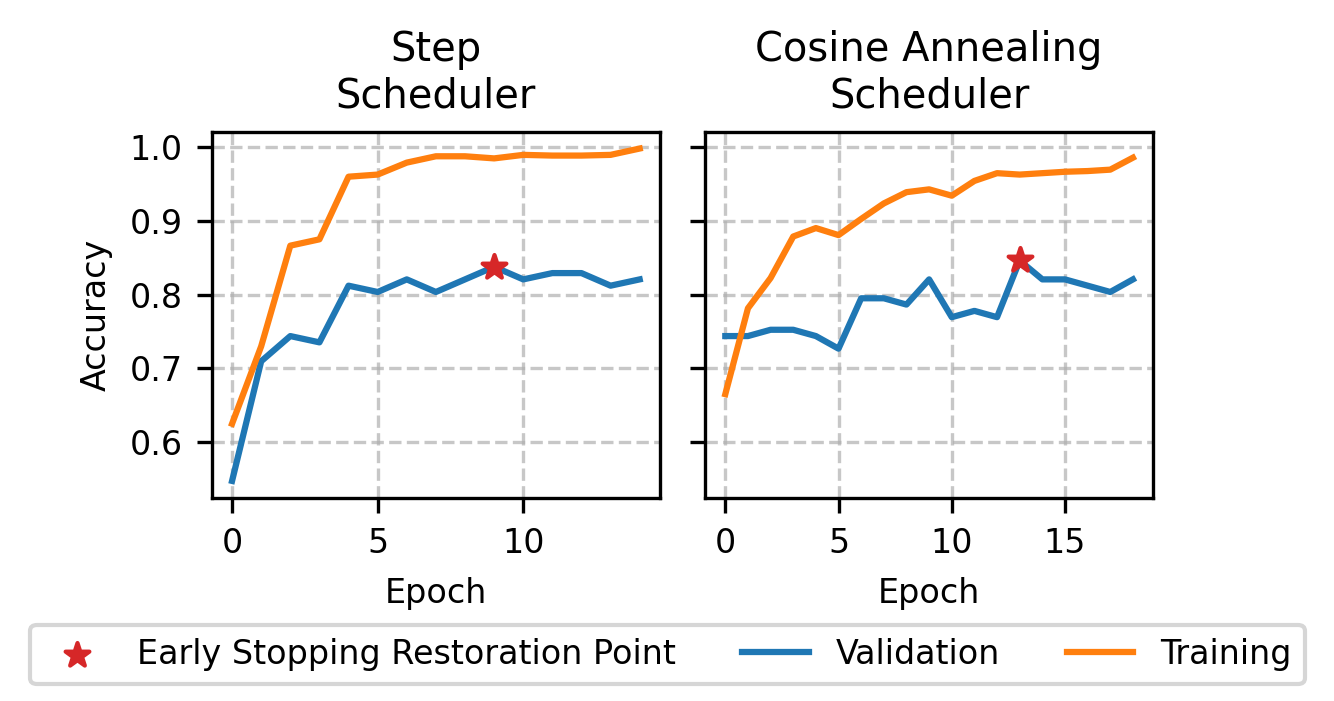

In [88]:
# Define the common model type to compare optimizers for
common_model_type = 'ConvNeXt-base-pretrained-clip' # Or pick ConvNeXt-base, ViT-B-32, etc.

# Define the two optimization strategies
optimizer_type_1 = 'StepLR'
optimizer_type_2 = 'CosineAnnealingWarmRestarts' 

# Configuration for Plotting (unchanged from previous working version)
OUTPUT_DIR = "performance_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURE_WIDTH = 6.75 * (3/5) 
FIGURE_HEIGHT = 3.25 * 0.6 # Adjusted height to maintain aspect ratio
# FONTSIZE_TITLE = 18
# FONTSIZE_SUBPLOT_TITLE = 16
# FONTSIZE_LABELS = 16
# FONTSIZE_TICKS = 16
# FONTSIZE_LEGEND = 16
DPI = 300
TICK_INTERVAL = 2 

# Create the figure and two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=DPI, sharey=True)

# Process and Plot for Optimizer Type 1
# Filter for the common model type AND the specific optimizer type
df_opt1 = experiment_results[
    (experiment_results['model'] == common_model_type) &
    (experiment_results['lr_scheduler_type'] == optimizer_type_1)
]

best_opt1_model_row = df_opt1.sort_values(by=['val_acc', 'val_roc_auc'], ascending=False).iloc[0]

# Extract and convert history data
train_loss_history_opt1 = ast.literal_eval(best_opt1_model_row['train_acc_history'])
val_loss_history_opt1 = ast.literal_eval(best_opt1_model_row['val_acc_history'])
NUM_EPOCHS = val_loss_history_opt1.index(None)

# Plot on the first subplot (axes[0])
axes[0].plot(val_loss_history_opt1)
axes[0].plot(train_loss_history_opt1)
# axes[0].set_xticks(np.arange(0, NUM_EPOCHS, TICK_INTERVAL))
axes[0].scatter(NUM_EPOCHS - 6, val_loss_history_opt1[NUM_EPOCHS - 6], color = 'tab:red', marker = '*', label = 'Early Stopping Restoration Point', zorder = 5)
axes[0].set_title(f'Step\nScheduler')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)
# axes[0].legend()

# Process and Plot for Optimizer Type 2 (e.g., Cosine Annealing)
# Filter for the common model type AND the specific optimizer type
df_opt2 = experiment_results[
    (experiment_results['model'] == common_model_type) &
    (experiment_results['lr_scheduler_type'] == optimizer_type_2)
]


best_opt2_model_row = df_opt2.sort_values(by='val_acc', ascending=False).iloc[0]

# Extract and convert history data
train_loss_history_opt2 = ast.literal_eval(best_opt2_model_row['train_acc_history'])
val_loss_history_opt2 = ast.literal_eval(best_opt2_model_row['val_acc_history'])
NUM_EPOCHS = val_loss_history_opt2.index(None)

axes[1].plot(val_loss_history_opt2, label='Validation')
axes[1].plot(train_loss_history_opt2, label='Training')
# axes[1].set_xticks(np.arange(0, NUM_EPOCHS, TICK_INTERVAL))
axes[1].scatter(NUM_EPOCHS - 6, val_loss_history_opt2[NUM_EPOCHS - 6], color = 'tab:red', marker = '*', zorder = 5)
axes[1].set_title(f'Cosine Annealing\nScheduler')
axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Loss', fontsize=FONTSIZE_LABELS)
axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')
axes[1].grid(axis='both', linestyle='--', alpha=0.7)
# axes[1].legend()

fig.legend(loc = 'lower center', ncol = 3)
# Add a main title for the entire figure
# fig.suptitle(f'ConvNeXt Learning Curves', y = 1.125)

# Adjust layout
# plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])
plt.subplots_adjust(bottom = 0.325, top = 0.95, wspace = 0.1)

# Save and display the plot
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves_by_scheduler.png"), bbox_inches='tight')
plt.show()

In [90]:
from deepfake_utils.models import MyModel

Extension horovod.torch has not been built: /anaconda/envs/azureml_py38_PT_TF/lib/python3.10/site-packages/horovod/torch/mpi_lib_v2.cpython-310-x86_64-linux-gnu.so not found
If this is not expected, reinstall Horovod with HOROVOD_WITH_PYTORCH=1 to debug the build error.
Warning! MPI libs are missing, but python applications are still available.


In [131]:
model = MyModel(model_type = 'ConvNeXt-base-pretrained-clip', device = device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-3)

/anaconda/envs/azureml_py38_PT_TF/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


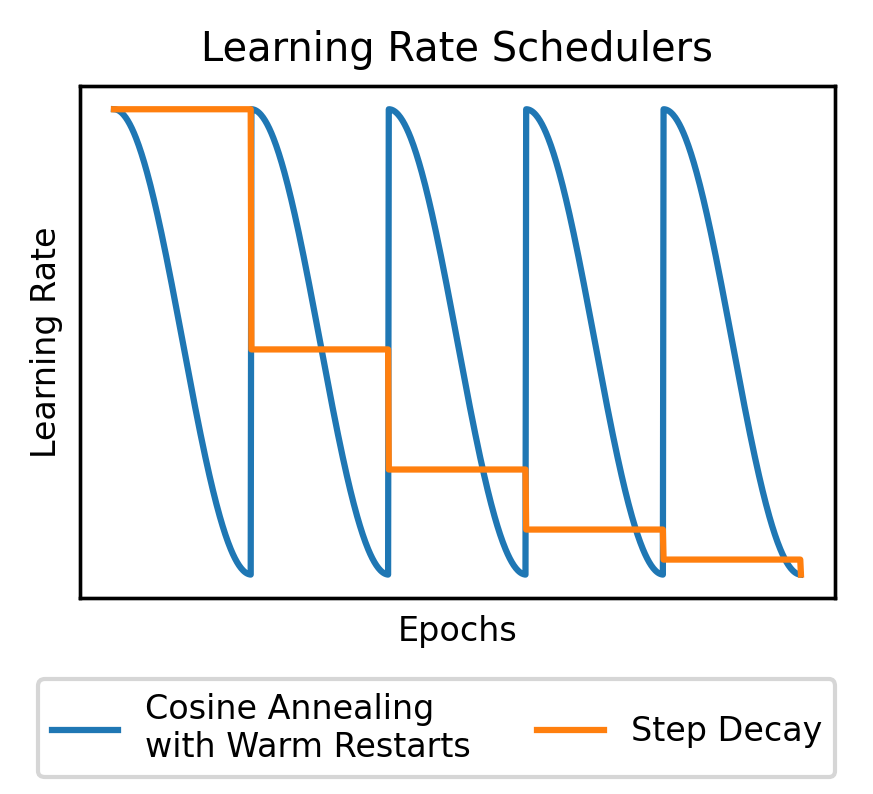

In [182]:
fig = plt.figure(figsize = (3.25, 3.25*0.75), dpi = 300)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=200, T_mult=1, eta_min=1e-6, last_epoch=-1
)
learning_rates = [lr_scheduler.get_last_lr()[0]]
for epoch in range(1000):
    lr_scheduler.step()
    learning_rates.append(lr_scheduler.get_last_lr()[0])
    
plt.plot(learning_rates[:-1], label = 'Cosine Annealing\nwith Warm Restarts')
# plt.ylim([0, 1.2e-5])
plt.yticks([])
plt.ylabel("Learning Rate")
plt.xlabel("Epochs")

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=200, gamma=0.5
)
learning_rates = [lr_scheduler.get_last_lr()[0]]
for epoch in range(1000):
    lr_scheduler.step()
    learning_rates.append(lr_scheduler.get_last_lr()[0])
plt.twinx()
plt.plot(learning_rates, color = 'C1', label = 'Step Decay')
# plt.ylim([0, 1.2e-5])
plt.yticks([])
plt.xticks([])
fig.legend(loc = 'lower center', ncol = 3)
plt.subplots_adjust(bottom = 0.25, top = 0.95, wspace = 0.1)
plt.title("Learning Rate Schedulers")
plt.savefig(os.path.join(OUTPUT_DIR, "learning_rate_schedulers.png"), bbox_inches='tight')
plt.show()